<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 8 - Model Selection and Cross validation</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

## Objective
In this TD, you will learn about model selection.

In [1]:
import numpy as np
import pandas as pd
from tqdm import trange

from bandit_task import ReversalBanditTask
from rl_models import RLModel, BiasRLModel, RepeatRLModel

In [2]:
%reload_ext autoreload
%autoreload 2

## The task
We will use behavioral data generated with the following `ReversalBanditTask`. It is displayed here so that you understand what we are working with, but since we work with experimental data, we will not need to perform model simulation in this TD.

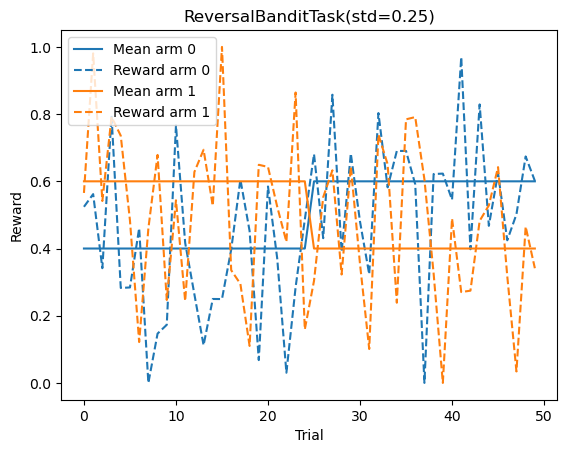

In [3]:
np.random.seed(42)
ReversalBanditTask(0.4, 0.6, 0.25, 50).plot()


## Dataset
### Load Participant Data
We will work with a dataset such as the ones you might work with when you run a study with participants. The data is in `experimental_data.csv`. Each line corresponds to a separate **trial**. The columns are the following:
- `subject_id`: the ID of the subject (starting from 1)
- `block`: the block number
- `trial`: the trial number
- `action`: the action taken by the subject (0 or 1)
- `reward`: the reward received by the subject

📝 Load the data and show the first 5 lines

In [4]:
# Solution
data = pd.read_csv('experimental_data.csv')
data.head()

,subject_id,block,trial,action,reward
0,1,0,0,1,0.565434
1,1,0,1,0,0.561922
2,1,0,2,0,0.341462
3,1,0,3,1,0.791859
4,1,0,4,1,0.735640


### Explore the data
In this section, we will explore the data to understand its structure and the number of trials, blocks, and subjects. This will involve finer mainpulations with the Pandas library. It is an occasion for you to practice your Pandas skills, but ask around to get some tips and make sure you don't spend more than 20-30 minutes on this section.

📝 Find how many subjects participated in the experiment

In [5]:
# Solution
data.subject_id.nunique()

3

📝 How many blocks were in the experiment?

In [6]:
# Solution
data.block.nunique()

8

📝 How many trials per block?

In [7]:
# Solution
data['trial'].nunique()

100

### Data processing
The trial-by-trial tabular format might be useful to save the data, but to feed it to RL models, we will need to transform it into a more compact format.

We will extract the data for each subject and stack the blocks together. The resulting data will be a 2D array of shape (n_blocks, n_trials) for both actions and rewards.

Let's try for one example.

📝Create a `subj_1_actions` array that contains the actions of subject 1 for all blocks. The shape of the array should be (8, 100) (8 blocks, 100 trials per block).

⚠️ Beware that in the data. the subjects are numbered starting from 1, while in Python, the indexing starts from 0.

In [8]:
# Solution
subj_1_actions = data[data['subject_id'] == 1]['action'].values.reshape(8, -1)

Now let's make a helper function to extract the data for a given subject.

📝 Complete the `extract_subject_data` funciton. It should take the subject ID as an argument and return the actions and rewards as 2D arrays of shape (n_blocks, n_trials).

In [9]:
# Solution (simple)
def extract_subject_data_easy(id: int, data=data):
    subj_data = data[data['subject_id'] == id]
    actions = subj_data['action'].values.reshape(8, -1)
    rewards = subj_data['reward'].values.reshape(8, -1)
    return actions, rewards

In [10]:
# Solution (more robust)
def extract_subject_data(id: int, data=data):
    subj_data = data[data['subject_id'] == id]
    block_actions = []
    block_rewards = []
    for block in range(8):
        block_actions.append(subj_data[subj_data['block'] == block]['action'])
        block_rewards.append(subj_data[subj_data['block'] == block]['reward'])
    actions = np.stack(block_actions, axis=0)
    rewards = np.stack(block_rewards, axis=0)
    return actions, rewards

Verify that the function works as expected by extracting the data for subject 1 and checking the shape of the arrays.

In [11]:
actions_subj_1, rewards_subj_1 = extract_subject_data(1)
actions_subj_1.shape, rewards_subj_1.shape

((8, 100), (8, 100))

## Define the models
We will compare the three variations of the Reinforcement Learning model with which we worked last time. They are already implemented in the `rl_models.py` file and have been imported in this notebook.

The `candidate_models` list below contains the three model classes that you will use for the model recovery. We will reuse it throughout the notebook.

The `model_names` is a list of the model names in string format. It will be used later to display the results of the model recovery in a more readable way.

In [12]:
candidate_models = [RLModel, BiasRLModel, RepeatRLModel]

model_names = [model.__name__ for model in candidate_models]
model_names

['RLModel', 'BiasRLModel', 'RepeatRLModel']

### Cross Validation
#### Step by step

📝 Extract the actions and rewards from subject 1 (number 1, not index 0)

In [13]:
# Solution
actions_s1, rewards_s1 = extract_subject_data(1)

📝 Extract blocks 1 and 2 separately

⚠️ Make sure that your actions and rewards remain 2D arrays of shape (n_blocks, n_trials), even if you only have one block. You can use the `reshape` method to do this.

In [14]:
# Solution
actions_s1_b0 = actions_s1[0].reshape(1, -1)
rewards_s1_b0 = rewards_s1[0].reshape(1, -1)

actions_s1_b1 = actions_s1[1].reshape(1, -1)
rewards_s1_b1 = rewards_s1[1].reshape(1, -1)

actions_s1_b2 = actions_s1[2].reshape(1, -1)
rewards_s1_b2 = rewards_s1[2].reshape(1, -1)

In [15]:
actions_s1_b1.shape, rewards_s1_b1.shape, actions_s1_b2.shape, rewards_s1_b2.shape

((1, 100), (1, 100), (1, 100), (1, 100))

📝 Fit a separate `RLModel` to each block's data.

In [16]:
# Solution
model_b0 = RLModel.fit(actions_s1_b0, rewards_s1_b0, verbose=False)
model_b1 = RLModel.fit(actions_s1_b1, rewards_s1_b1, verbose=False)
model_b2 = RLModel.fit(actions_s1_b2, rewards_s1_b2, verbose=False)


Validation means computing the log likelihood of the model on a block of data that was not used for fitting. The log likelihood is a measure of how well the model explains the data. The higher the log likelihood, the better the model fits the data. We will compare the likelihoods of a model on its fitting data and on unseen data.

📝 Validate all three models on the data from block 0.


In [17]:
# Solution
ll_model_b0_val_b0 = model_b0.log_likelihood(actions_s1_b0, rewards_s1_b0)
ll_model_b1_val_b0 = model_b1.log_likelihood(actions_s1_b0, rewards_s1_b0)
ll_model_b2_val_b0 = model_b2.log_likelihood(actions_s1_b0, rewards_s1_b0)

💭 Which model has the best likelihood on data from block 0? Is it surprising?

In [18]:
# Solution
pd.Series({
    'Model fit on block 0': ll_model_b0_val_b0,
    'Model fit on block 1': ll_model_b1_val_b0,
    'Model fit on block 2': ll_model_b2_val_b0,
}, name='likelihood on block 0').sort_values(ascending=False)

Model fit on block 0   -41.158661
Model fit on block 2   -41.690369
Model fit on block 1   -42.692067
Name: likelihood on block 0, dtype: float64

#### Fitting on many blocks and validating on 1 block
What we usually do when we have many blocks is that we fit the data to a large portion of the blocks, and keep a small portion for validation. This provides a better estimate of the fit. Here, we will use 7 blocks for fitting and 1 block for validation.

📝 Extract again the data from subject 1

In [19]:
actions_s1, rewards_s1 = extract_subject_data(1)

📝 Extract the fitting and validation data. For the exercise, keep block 4 for validation.
> - You can slice numpy arrays to select rows, and use the np.delete() function to remove a specific row from an array
> - Again, check that your arrays remain 2D, even if there is just one block

In [20]:
# Solution
fit_actions = np.delete(actions_s1, 4, axis=0)
fit_rewards = np.delete(rewards_s1, 4, axis=0)

val_actions = actions_s1[4].reshape(1, -1)
val_rewards = rewards_s1[4].reshape(1, -1)

📝 Fit an `RLModel` to the fitting data

In [21]:
# Solution
fitted_model = RLModel.fit(fit_actions, fit_rewards, verbose=False)

📝 Compute the log likelihood on the validation data

In [22]:
# Solution
log_likelihood = fitted_model.log_likelihood(val_actions, val_rewards)
log_likelihood

np.float64(-22.70589121799971)

#### Full cross validation loop
Now let's put all this code in a loop that will perform 8 validations, using each block for validation.

📝 Fill the `cross_validation` function

In [23]:
# Solution
def cross_validation(model_class, actions, rewards):
    n_blocks = 8
    cv_log_likelihood = 0
    for val_block in trange(n_blocks, desc=f'Cross-validation {model_class.__name__}', unit='block'):
        # Extract fitting data and validation data
        fit_actions = np.delete(actions, val_block, axis=0)
        fit_rewards = np.delete(rewards, val_block, axis=0)

        val_actions = actions[val_block, :].reshape(1, -1)
        val_rewards = rewards[val_block, :].reshape(1, -1)

        fitted_model = model_class.fit(fit_actions, fit_rewards, verbose=False)

        # Compute validation log likelihood
        log_likelihood = fitted_model.log_likelihood(val_actions, val_rewards)
        cv_log_likelihood += log_likelihood

    return cv_log_likelihood

In [24]:
cross_validation(RLModel, *extract_subject_data(1))

Cross-validation RLModel: 100%|██████████| 8/8 [00:04<00:00,  1.78block/s]


np.float64(-262.4873344520112)

# Model Selection

### Selection Criteria
Let's reuse the criteria from last TD to compare with Cross Validation.### Selection Criteria

#### Log likelihood
📝 Complete the `loglikelihood_evaluation` function. It is slightly different from last week because now it takes a model class, that you have to first fit to the data. As we have seen, log likelihood is not an appropriate criterion, but we will use it for comparison.

> ⚠️ Make sure it returns a float, not an array!

In [25]:
# Solution
def loglikelihood_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)
    return ll

#### Bayesian Information Criterion (BIC)
$$
\text{BIC} = -2 \cdot \log L + k \cdot \log n
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model
- $n$ is the number of data points

📝 Complete the `bic_evaluation` function.

In [26]:
# Solution
def bic_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)

    k = model_class.n_params
    n = actions.size    # Watch out for this one: n = n_trials * n_blocks
    bic = -2 * ll + k * np.log(n)
    return bic

### Akaike Information Criterion (AIC)
$$
\text{AIC} = -2 \cdot \log L + 2k
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model

📝 Complete the `aic_evaluation` function.

In [27]:
# Solution
def aic_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)

    k = model_class.n_params
    aic = -2 * ll + 2 * k
    return aic

### Model Selection on Subject 1
Now let's perform model selection to find what model best explains the behavior of Subject 1.

📝 Complete the `evaluate_models` function. 
- It sould take a list of model classes to evaluate
- It should take in the actions and rewards of a specific subject (as they are produced by the `extract_subject_data` function).
- It should evaluate each model on all four criteria:
    - log likelihood
    - BIC
    - AIC
    - Cross-validation
- It should return the results in a DataFrame with rows indicating the model names and columns indicating the criteria.

In [28]:
# Solution
criteria = ['LL', 'BIC', 'AIC', 'CV']
def evaluate_models(model_classes, actions, rewards):
    results = pd.DataFrame(index=model_names, columns=criteria)
    
    for model_name, model_class in zip(model_names, model_classes):
        results.loc[model_name, 'LL'] = loglikelihood_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'BIC'] = bic_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'AIC'] = aic_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'CV'] = cross_validation(model_class, actions, rewards)
    return results

Run your `evaluate_models` function with data from subject 1.

In [29]:
eval_s1 = evaluate_models(candidate_models, *extract_subject_data(1))
eval_s1

Cross-validation RepeatRLModel: 100%|██████████| 8/8 [00:04<00:00,  1.68block/s]


,LL,BIC,AIC,CV
RLModel,-260.00232,533.373887,524.004642,-262.495845
BiasRLModel,-260.002288,540.0587,526.004821,-263.209779
RepeatRLModel,-259.44041,538.934612,524.881029,-263.481169


### Subject-wise model selection
Now let's find out what model best explain each subject's behavior.

#### Evaluate all models on all subjects

We will start by running the `evaluate_models` function that we just wrote on the data from all subjects.

📝 Fill the code below to store the results from all subjects in a list.

In [30]:
# Solution
subj_evals = []

subject_ids = data['subject_id'].unique() # List of all subject ids
for subject_id in subject_ids:
    print(f"Evaluating data from subject {subject_id}") 
    actions, rewards = extract_subject_data(subject_id)
    evaluation = evaluate_models(candidate_models, actions, rewards)
    subj_evals.append(evaluation)

subj_evals

Evaluating data from subject 1


Cross-validation RepeatRLModel: 100%|██████████| 8/8 [00:04<00:00,  1.67block/s]


Evaluating data from subject 2


Cross-validation RepeatRLModel: 100%|██████████| 8/8 [00:05<00:00,  1.58block/s]


Evaluating data from subject 3


Cross-validation RepeatRLModel: 100%|██████████| 8/8 [00:09<00:00,  1.19s/block]


[                       LL         BIC         AIC          CV
 RLModel       -260.003034  533.373863  524.004639 -262.486341
 BiasRLModel   -260.002878  540.059147  526.004794 -263.232297
 RepeatRLModel -259.440505  538.934908  524.880767 -263.464611,
                        LL         BIC         AIC          CV
 RLModel       -256.636058  526.641486  517.272162 -261.312973
 BiasRLModel   -213.499007   447.04942  432.995383 -217.162462
 RepeatRLModel  -239.79803  499.650231  485.596422 -244.348847,
                        LL         BIC         AIC          CV
 RLModel       -436.774437  886.918101  877.549324  -440.75487
 BiasRLModel   -435.195146  890.444069  876.390276 -440.889313
 RepeatRLModel -387.826538  795.706948  781.652723 -390.757362]

Now run this cell to pack all this into a nice-looking DataFrame with two levels of column labels.

In [31]:
subject_results = pd.concat(subj_evals, keys=subject_ids).unstack()
subject_results

LL                                   BIC                            \
      RLModel BiasRLModel RepeatRLModel     RLModel BiasRLModel RepeatRLModel   
1 -260.003034 -260.002878   -259.440505  533.373863  540.059147    538.934908   
2 -256.636058 -213.499007    -239.79803  526.641486   447.04942    499.650231   
3 -436.774437 -435.195146   -387.826538  886.918101  890.444069    795.706948   

          AIC                                    CV                            
      RLModel BiasRLModel RepeatRLModel     RLModel BiasRLModel RepeatRLModel  
1  524.004639  526.004794    524.880767 -262.486341 -263.232297   -263.464611  
2  517.272162  432.995383    485.596422 -261.312973 -217.162462   -244.348847  
3  877.549324  876.390276    781.652723  -440.75487 -440.889313   -390.757362

#### Select best model on all subjects
We can make these results even easier to read!

📝 Complete the code below select, for each subject and each criterion, the best-scoring model. The resulting `model_selection` DataFrame should be 2-dimensional, with rows corresponding to subjects, columns to criteria, and cells showing the name of the winning model.

In [32]:
# Solution
subject_ids = data['subject_id'].unique()
model_selection = pd.DataFrame(index=subject_ids, columns=criteria)
for subject_id in subject_ids:
    model_selection.loc[subject_id, 'LL'] = subject_results.loc[subject_id, 'LL'].idxmax()
    model_selection.loc[subject_id, 'BIC'] = subject_results.loc[subject_id, 'BIC'].idxmin()
    model_selection.loc[subject_id, 'AIC'] = subject_results.loc[subject_id, 'AIC'].idxmin()
    model_selection.loc[subject_id, 'CV'] = subject_results.loc[subject_id, 'CV'].idxmax()

model_selection

,LL,BIC,AIC,CV
1,RepeatRLModel,RLModel,RLModel,RLModel
2,BiasRLModel,BiasRLModel,BiasRLModel,BiasRLModel
3,RepeatRLModel,RepeatRLModel,RepeatRLModel,RepeatRLModel
